# 00. Homework description

For this assignment, your task is to develop the [FastPitch](https://arxiv.org/abs/2006.06873) synthesis model, train it, and generate several audio samples.

The training and data processing code has already been provided for you. The training will be conducted on the LJspeech dataset.

The total score for the homework is **10 points**, distributed as follows:
- 1 point for visualizing the input data
- 8 points for writing the model code and running training
- 1 point for pitch and duration manipulations during inference

The homework submission **should include**:
- Completed notebook
- Attached WER and loss graphs from TensorBoard
- 1 audio file - the result of a regular model inference
- 4 additional audio files: you are encouraged to experiment with adjusting phoneme durations and pitch slightly and listen to the results.

# 01. Preparation steps

In [ ]:
device = "cuda"
gpu_avaiable = "0"    # Run nvidia-smi to find free GPU

In [230]:
path_to_sources = '../../week_08_tts_am_vocoders'  # Path to the the current week's source code, e.g. /home/user/speech_course/week_08_tts_am_vocoders

In [4]:
# If running in colab

# clone the repository:
# git clone https://github.com/yandexdataschool/speech_course.git
# !pip install -r speech_course/week_08_tts_am_vocoders/requirements.txt

### Dataset

We will work with [LJSpeech](https://keithito.com/LJ-Speech-Dataset/) -- a single-speaker dataset with 24 hours of speech.

The data we will use contains pre-computed [MFA-alignments](https://montreal-forced-aligner.readthedocs.io/en/latest/user_guide/workflows/alignment.html) alongside with the original wavs and texts. If you are interested in the process of extracting such alignments, please refer to this [tutorial](https://colab.research.google.com/gist/NTT123/12264d15afad861cb897f7a20a01762e/mfa-ljspeech.ipynb).

Download the dataset with precomputed alignments.

In [ ]:
# import requests
# from urllib.parse import urlencode
# from io import BytesIO
# from zipfile import ZipFile

# base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'
# public_key = 'https://disk.yandex.ru/d/PpgePfWcQTAbug'

# final_url = base_url + urlencode(dict(public_key=public_key))
# response = requests.get(final_url)
# download_url = response.json()['href']
# response = requests.get(download_url)

# path_to_dataset = 'data'    # Choose any appropriate local path

# # If running in Colab:
# # path_to_dataset = '/data'

# zipfile = ZipFile(BytesIO(response.content))
# zipfile.extractall(path=path_to_dataset)

### Hi-Fi GAN checkpoint


Download a pretrained Hi-Fi GAN checkpoint (to generate audio from the predicted mel-spectrograms).

In [6]:
# import wget

# wget.download('https://api.ngc.nvidia.com/v2/models/nvidia/dle/hifigan__pyt_ckpt_ds-ljs22khz/versions/21.08.0_amp/zip', out='../sources/hifigan/hifigan_ckpt.zip')

In [7]:
# In colab:
# !wget --content-disposition https://api.ngc.nvidia.com/v2/models/nvidia/dle/hifigan__pyt_ckpt_ds-ljs22khz/versions/21.08.0_amp/zip -O /content/hifigan_ckpt.zip
# !unzip /content/hifigan_ckpt.zip
# !rm /content/hifigan_ckpt.zip

In [8]:
path_to_hfg_ckpt = "../sources/hifigan/hifigan_gen_checkpoint_6500.pt" 

### Imports

In [26]:
import sys
import os
import json
import dataclasses
import torch
import numpy as np
import subprocess as sp
import matplotlib.pylab as plt
import soundfile as sf
import librosa
import nltk
nltk.download('averaged_perceptron_tagger_eng')

from g2p_en import G2p
import IPython.display as Ipd

import typing as tp

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\nazmievairat\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


In [10]:
sys.path.append(path_to_sources)

# 02. See a data sample (1 point)

In [11]:
from sources.fastpitch.hparams import HParamsFastpitch
from sources.fastpitch.data import prepare_loaders, SymbolsSet

The mfa alignment provides phonemes and their durations, which we will need during training:

In [12]:
path_to_dataset = 'data'

In [23]:
with open(os.path.join(path_to_dataset, 'mfa_aligned', 'LJ001-0001.json')) as f:
    utterance = json.load(f)

utterance

{'start': 0,
 'end': 9.655062,
 'tiers': {'words': {'type': 'interval',
   'entries': [[0.0, 0.69, 'printing'],
    [0.69, 0.82, '<eps>'],
    [0.82, 1.01, 'in'],
    [1.01, 1.15, 'the'],
    [1.15, 1.45, 'only'],
    [1.45, 1.97, 'sense'],
    [1.97, 2.14, 'with'],
    [2.14, 2.39, 'which'],
    [2.39, 2.54, 'we'],
    [2.54, 2.71, 'are'],
    [2.71, 2.89, 'at'],
    [2.89, 3.28, 'present'],
    [3.28, 4.0, 'concerned'],
    [4.0, 4.41, '<eps>'],
    [4.41, 5.01, 'differs'],
    [5.01, 5.04, '<eps>'],
    [5.04, 5.28, 'from'],
    [5.28, 5.65, 'most'],
    [5.65, 5.82, 'if'],
    [5.82, 6.1, 'not'],
    [6.1, 6.29, 'from'],
    [6.29, 6.63, 'all'],
    [6.63, 6.78, 'the'],
    [6.78, 7.09, 'arts'],
    [7.09, 7.22, 'and'],
    [7.22, 7.8, 'crafts'],
    [7.8, 8.45, 'represented'],
    [8.45, 8.66, 'in'],
    [8.66, 8.79, 'the'],
    [8.79, 9.6, 'exhibition'],
    [9.6, 9.655062, '<eps>']]},
  'phones': {'type': 'interval',
   'entries': [[0.0, 0.04, 'P'],
    [0.04, 0.07, 'R'],
    [0

Phoneme `sil` (silence) here denotes pause -- a period of silence between spoken phonemes. The phonemes are from [ARPA](https://en.wikipedia.org/wiki/ARPABET) alphabet.

In [208]:
hparams = HParamsFastpitch()
train_loader, val_loader = prepare_loaders(path_to_dataset, hparams)

In [209]:
val_iter = iter(val_loader)
batch = next(val_iter)

In [210]:
list(dataclasses.asdict(batch).keys())

['texts',
 'text_lengths',
 'mels',
 'mel_lengths',
 'pitches',
 'durations',
 'paces']

In [211]:
print(f'{batch.texts.shape = }\n{batch.mels.shape = }\n{batch.pitches.shape = }\n{batch.durations.shape = }')

batch.texts.shape = torch.Size([10, 97])
batch.mels.shape = torch.Size([10, 80, 802])
batch.pitches.shape = torch.Size([10, 97])
batch.durations.shape = torch.Size([10, 97])


## Task

**(0.5 points)** Draw a combined image showing both the mel-spectrogram and pitch for a sample from the batch. Use durations to ensure proper alignment of their shapes in the image.  
**(0.5 points)** Include phoneme labels near the time axis on the image from the previous step. (like in Figure 3 in the [paper](https://arxiv.org/pdf/2006.06873.pdf)). You may find the code from the seminar helpful.

In [212]:
phoneme_ids_decoder = SymbolsSet().decode

def decode_phoneme_ids(text: torch.Tensor, text_length: tp.Optional[torch.Tensor] = None) -> list[list[str]]:
    if text_length is not None:
        text = text[:text_length]
    return phoneme_ids_decoder(text.tolist())

In [213]:
def hz_to_mel(frequency: torch.Tensor) -> torch.Tensor:
    return 2595.0 * torch.log10(1.0 + frequency / 700.0)

def frequency_to_mel_bin(frequency: torch.Tensor,
                         n_mels: int = 80,
                         f_min: float = 0.0,
                         f_max: float = 8000.0) -> torch.Tensor:    
    mel_f = librosa.mel_frequencies(n_mels=n_mels+2, fmin=f_min, fmax=f_max)
    
    mel_frequency = hz_to_mel(frequency)
    
    bin_indices = torch.zeros_like(frequency, dtype=torch.long)
    
    for i in range(n_mels):
        lower_edge = hz_to_mel(torch.tensor(mel_f[i],))
        upper_edge = hz_to_mel(torch.tensor(mel_f[i+1]))
        
        in_bin = (mel_frequency >= lower_edge) & (mel_frequency < upper_edge)
        bin_indices[in_bin] = i
    
    bin_indices[mel_frequency >= hz_to_mel(torch.tensor(mel_f[-2]))] = n_mels - 1
    
    return bin_indices

In [228]:
def visualize_mels_pitch_phonemes(mels, mel_length, phoneme_ids, phoneme_durations, phoneme_length, pitches, figsize=None, dpi=100):
    if mel_length is not None:
        mels = mels[:, :mel_length]
        pitches = pitches[:mel_length]
    if figsize is None:
        fig, ax = plt.subplots(sharex=True, dpi=dpi)
    else:
        fig, ax = plt.subplots(figsize=figsize, sharex=True, dpi=dpi)
        
    # LJSpeech constants
    normalize_mean=215.42230
    normalize_std=62.51305
        
    pitches = pitches * normalize_std + normalize_mean
    pitches_mel_bin = frequency_to_mel_bin(pitches)
    
    ax.set_xlabel("frame idx")
    ax.set_ylabel("mel freq idx")
    ax.imshow(mels, origin='lower')
    
    phonemes = decode_phoneme_ids(phoneme_ids, phoneme_length)
    phoneme_edges = torch.nn.functional.pad(torch.cumsum(phoneme_durations[:phoneme_length], dim=0), pad=(1, 0))
    for idx, (edge_l, edge_r) in enumerate(zip(phoneme_edges[:-1], phoneme_edges[1:])):
        y_shift = (idx % 3 == 1) * 10 + (idx % 3 == 2) * 20
        ax.text(
            x=0.99 * edge_l + 0.01 *edge_r,
            y=50 + y_shift, 
            s=phonemes[idx],
            fontsize=5,
            weight='bold'
        )
    
    for s in phoneme_edges:
        ax.axvline(x=s-0.5, c='r', lw=0.5)
    
    for pitch_mel_bin, edge_left, edge_right in zip(pitches_mel_bin, phoneme_edges[:-1], phoneme_edges[1:]):
        ax.hlines(y=pitch_mel_bin.item(), xmin=edge_left.item()-0.5, xmax=edge_right.item()-0.5, colors='k', lw=0.7)
    
    ax.minorticks_on()
    fig.tight_layout()
    plt.show()

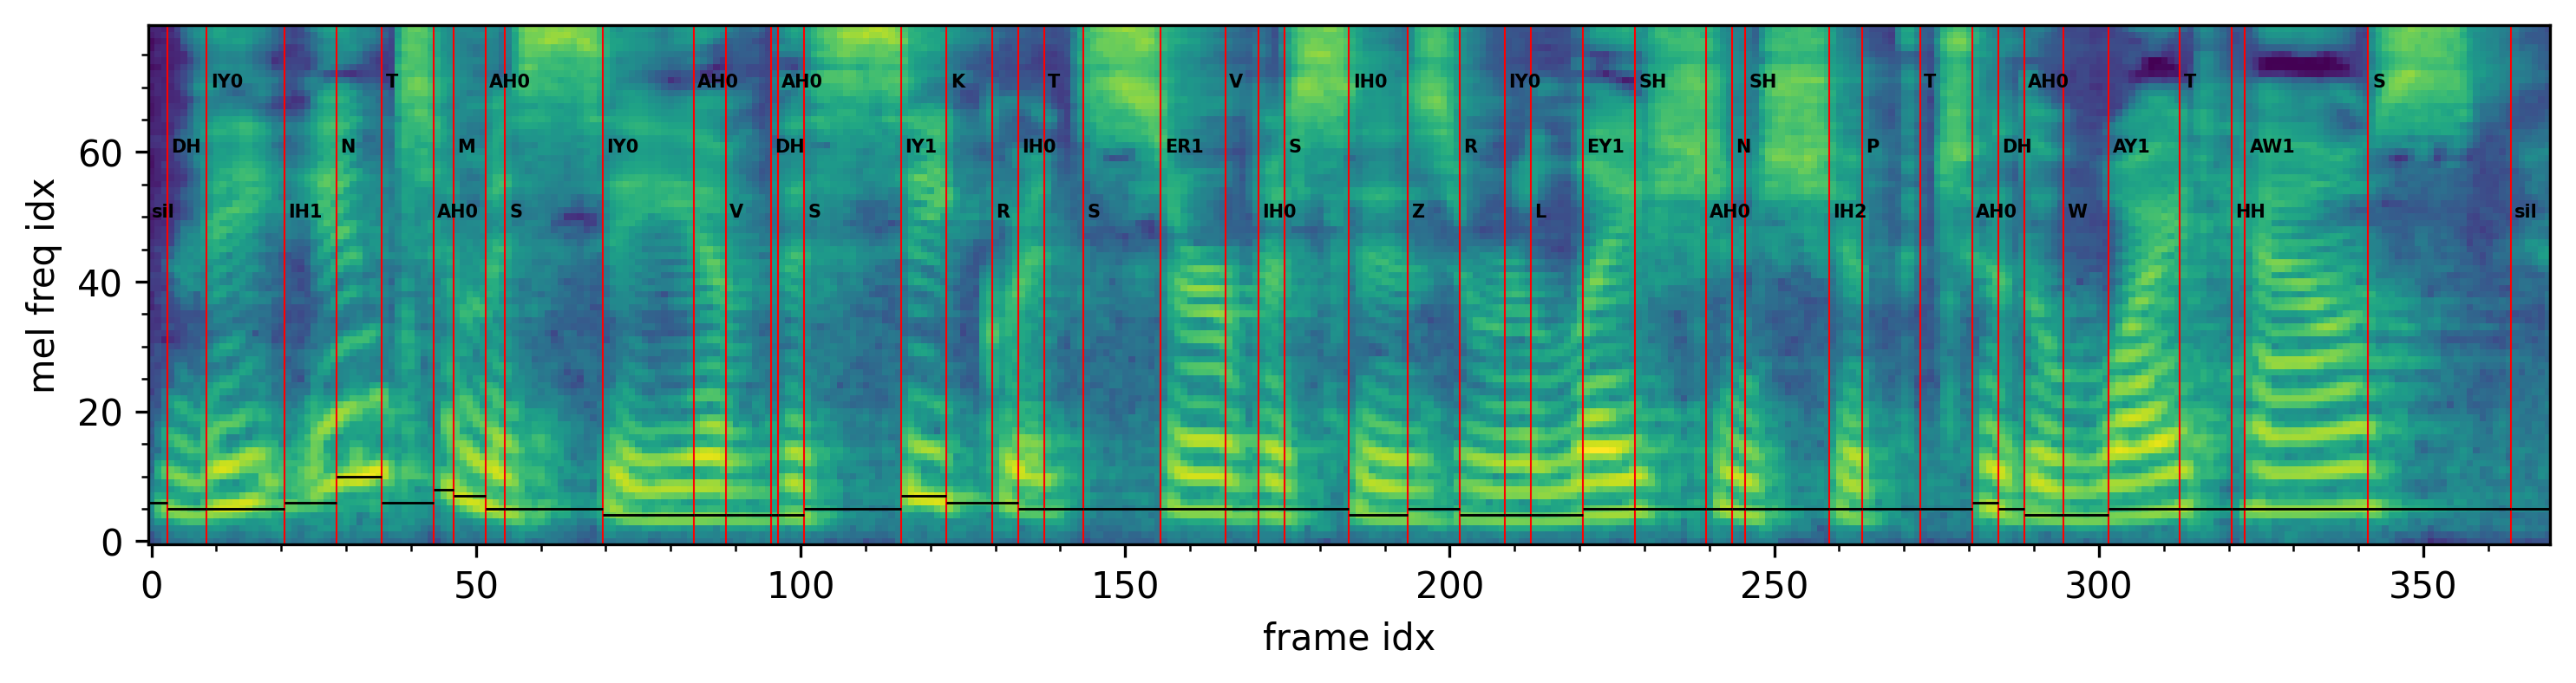

sil DH IY0 IH1 N T AH0 M AH0 S IY0 AH0 V DH AH0 S IY1 K R IH0 T S ER1 V IH0 S IH0 Z R IY0 L EY1 SH AH0 N SH IH2 P T AH0 DH AH0 W AY1 T HH AW1 S sil


In [229]:
# Text (val, batch_idx = 3): 
# The intimacy of the Secret Service's relationship to the White House

batch_idx = 3

visualize_mels_pitch_phonemes(
    batch.mels[batch_idx], 
    batch.mel_lengths[batch_idx], 
    phoneme_ids=batch.texts[batch_idx], 
    phoneme_durations=batch.durations[batch_idx], 
    phoneme_length=batch.text_lengths[batch_idx],
    pitches=batch.pitches[batch_idx],
    figsize=(10, 30),
    dpi=300
)
print(' '.join(decode_phoneme_ids(batch.texts[batch_idx], batch.text_lengths[batch_idx])))

# 03. Implement FastPitch model (9 points)

Please implement the FastPitch model in the cell provided below. Running this cell will overwrite the model file in the repository. 
- Run training (see next cells)
- Run inference (see next cells)
- When submitting the homework, please include
   - the Word Error Rate (WER) and loss curves obtained from TensorBoard as attachments,
   - the generated audio (see inference cells). If attaching an archive, use the name: `prediction.wav`

By the end of training, the loss should reach approximately 0.69, and WER should be close to zero (around 0.006). The training process will take about 30 minutes (3,000 batches).

**Important:** By the end of the training, the generated audio sample must be clear in terms of speech (WER close to 0) and maintain audio quality comparable to the original recordings (as logged in TensorBoard). **If these conditions are not met, the entire section will receive zero points**, regardless of how closely the model code resembles working code. Here is an example of how an audio from a well-trained model may sound:

In [22]:
audio, sr = sf.read('prediction_example.wav')
Ipd.display(Ipd.Audio(audio, rate=sr))

In [ ]:
#%%writefile ../sources/fastpitch/model.py
import torch
from torch import nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
import typing as tp

from sources.fastpitch.common.layers import TemporalPredictor
from sources.fastpitch.common.utils import DeviceGetterMixin
from sources.fastpitch.common.utils import regulate_len
from sources.fastpitch.data import FastPitchBatch, SymbolsSet
from sources.fastpitch.hparams import HParamsFastpitch
from sources.fastpitch.common.transformer import FFTransformer


class FastPitch(nn.Module, DeviceGetterMixin):
    def __init__(self, hparams: HParamsFastpitch):
        super().__init__()
        self.hparams = hparams
        n_symbols = len(SymbolsSet().symbols_to_id)

        self.symbol_emb = nn.Embedding(n_symbols, hparams.symbols_embedding_dim)

        self.encoder = FFTransformer(
            n_layer=hparams.in_fft_n_layers,
            n_head=hparams.in_fft_n_heads,
            d_model=hparams.symbols_embedding_dim,
            d_head=hparams.in_fft_d_head,
            d_inner=4 * hparams.symbols_embedding_dim,
            kernel_size=hparams.in_fft_conv1d_kernel_size,
            dropout=hparams.p_in_fft_dropout,
            dropatt=hparams.p_in_fft_dropatt,
            dropemb=hparams.p_in_fft_dropemb
        )

        self.duration_predictor = TemporalPredictor(
            input_size=hparams.symbols_embedding_dim,
            filter_size=hparams.dur_predictor_filter_size,
            kernel_size=hparams.dur_predictor_kernel_size,
            dropout=hparams.p_dur_predictor_dropout,
            n_layers=hparams.dur_predictor_n_layers
        )

        self.pitch_predictor = TemporalPredictor(
            input_size=hparams.symbols_embedding_dim,
            filter_size=hparams.pitch_predictor_filter_size,
            kernel_size=hparams.pitch_predictor_kernel_size,
            dropout=hparams.p_pitch_predictor_dropout,
            n_layers=hparams.pitch_predictor_n_layers
        )

        self.pitch_emb = nn.Conv1d(1, hparams.symbols_embedding_dim, kernel_size=3, padding=1)

        self.decoder = FFTransformer(
            n_layer=hparams.out_fft_n_layers,
            n_head=hparams.out_fft_n_heads,
            d_model=hparams.symbols_embedding_dim,
            d_head=hparams.out_fft_d_head,
            d_inner=4 * hparams.symbols_embedding_dim,
            kernel_size=hparams.out_fft_conv1d_kernel_size,
            dropout=hparams.p_out_fft_dropout,
            dropatt=hparams.p_out_fft_dropatt,
            dropemb=hparams.p_out_fft_dropemb
        )

        self.proj = nn.Linear(hparams.symbols_embedding_dim, hparams.n_mel_channels, bias=True)
        
    # def repeat_enc_out(self, durations, enc_out):
    #     repeats = torch.round(durations).long()
    #     enc_out_rep = pad_sequence(
    #         [torch.repeat_interleave(outp, reps, dim=0) for outp, reps in zip(enc_out, repeats)],
    #         batch_first=True
    #     )
    #     dec_lens = repeats.sum(dim=1)
        
    #     return enc_out_rep, dec_lens

    def get_encoder_out(self, batch: FastPitchBatch):
        '''
        Return: 
        enc_out: 
            Output of the first series of FFT blocks (before adding pitch embedding)
            shape: (batch, len(text), symbols_embedding_dim)
        enc_mask:
            Boolean padding mask for the input text sequences
            shape: (batch, len(text), 1)
        '''
        text_emb = self.symbol_emb(batch.texts)
        enc_out, enc_mask = self.encoder(text_emb, batch.text_lengths)
        
        return enc_out, enc_mask

    def forward(
        self, 
        batch: FastPitchBatch, 
        use_gt_durations: bool = True, 
        use_gt_pitch: bool = True, 
        max_duration: int = 75
    ) -> tp.Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        '''
        Flags `use_gt_durations` and `use_gt_pitch` should be both True during training and either True or False during inference.

        Use the function `regulate_len` to duplicate phonemes according to durations before passing them to the decoder.
        
        Return:
        mel_out:
            Predicted mel-spectrograms
            shape: (batch, time, mel_bins)
        mel_lens:
            Number of time frames in each of the predicted spectrograms
            shape: (batch,)
        log_dur_pred:
            The predicted log-durations for each phoneme (the output of the duration predictor).
            shape: (batch, len(text))
        dur_pred:
            The exponent of the predicted log-durations for each phoneme. Clamped to the range (0, max_duration) for numeric stability
            shape: (batch, len(text))
        pitch_pred:
            The predicted pitch for each phoneme
            shape: (batch, len(text))
        '''
        
        enc_out, enc_mask = self.get_encoder_out(batch)
        
        log_dur_pred = self.duration_predictor(enc_out, enc_mask)
        dur_pred = torch.clamp(torch.exp(log_dur_pred) - 1, min=0, max=max_duration)
        
        pitch_pred = self.pitch_predictor(enc_out, enc_mask)
        
        if use_gt_pitch:
            pitches = batch.pitches
        else:
            pitches = pitch_pred
            
        pitch_emb = self.pitch_emb(pitches.unsqueeze(1))
        enc_out = enc_out + pitch_emb.transpose(1, 2)
        
        if use_gt_durations:
            durations = batch.durations
        else:
            durations = dur_pred
            
        enc_out_rep, mel_lens, reps = regulate_len(durations, enc_out, batch.paces)
            
        dec_out, dec_mask = self.decoder(enc_out_rep, mel_lens)
        mel_out = self.proj(dec_out)
        
        return mel_out, mel_lens, dur_pred, log_dur_pred, pitch_pred

    @torch.no_grad()
    def infer(
        self, 
        batch: FastPitchBatch, 
        max_duration: int = 75
    ) -> tp.Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        enc_out, dur_pred, pitch_pred = self.infer_encoder(batch, max_duration=max_duration)
        mel_out, mel_lens = self.infer_decoder(enc_out, dur_pred)
        return mel_out, mel_lens, dur_pred, pitch_pred

    def infer_encoder(
        self, 
        batch: FastPitchBatch, 
        max_duration: int = 75
    ) -> tp.Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        enc_out, enc_mask = self.get_encoder_out(batch)
        
        log_dur_pred = self.duration_predictor(enc_out, enc_mask)
        dur_pred = torch.clamp(torch.exp(log_dur_pred) - 1, min=0, max=max_duration)
        
        pitch_pred = self.pitch_predictor(enc_out, enc_mask)
        pitch_emb = self.pitch_emb(pitch_pred.unsqueeze(1))
        
        enc_out = enc_out + pitch_emb.transpose(1, 2)
        
        return enc_out, dur_pred, pitch_pred

    def infer_decoder(
        self, 
        enc_out: torch.Tensor, 
        dur_pred: torch.Tensor
    ) -> tp.Tuple[torch.Tensor, torch.Tensor]:
        enc_out_rep, mel_lens, reps = regulate_len(dur_pred, enc_out) #self.repeat_enc_out(dur_pred, enc_out)
        dec_out, dec_mask = self.decoder(enc_out_rep, mel_lens)
        mel_out = self.proj(dec_out)
        
        return mel_out, mel_lens


In [27]:
%load_ext autoreload
%autoreload 2
from sources.fastpitch.model import FastPitch

In [28]:
fp = FastPitch(hparams)

In [29]:
enc_out, enc_mask = fp.get_encoder_out(batch)

In [30]:
assert enc_out.shape == torch.Size([hparams.batch_size, batch.texts.shape[1], hparams.symbols_embedding_dim])
assert enc_mask.shape == torch.Size([hparams.batch_size, batch.texts.shape[1], 1])

In [31]:
mel_out, mel_lens, dur_pred, log_dur_pred, pitch_pred = fp.forward(batch)

In [32]:
assert mel_out.shape == batch.mels.transpose(2, 1).shape
assert mel_lens.shape == batch.mel_lengths.shape
assert dur_pred.shape == batch.texts.shape
assert dur_pred.shape == log_dur_pred.shape
assert pitch_pred.shape == batch.texts.shape

### Run training

In [ ]:
logs_dir = "logs"
ckpt_dir = "checkpoints"

In [35]:
os.makedirs(logs_dir, exist_ok=True)
os.makedirs(ckpt_dir, exist_ok=True)

In [37]:
# sp.check_call(
#     ' '.join([
#         f'PYTHONPATH={path_to_sources} CUDA_VISIBLE_DEVICES={gpu_avaiable}',
#         f'python -m sources.fastpitch.train_fastpitch',
#         f'--logs {logs_dir}',
#         f'--ckptdir {ckpt_dir}',
#         f'--dataset {path_to_dataset}',
#         f'--hfg {path_to_hfg_ckpt}'
#     ]), shell=True
# )

In [ ]:
# env = os.environ.copy()
# env["PYTHONPATH"] = path_to_sources
# env["CUDA_VISIBLE_DEVICES"] = "0"#gpu_avaiable

# # Build the command as a list for better handling in Windows.
# command = [
#     "python", "-m", "sources.fastpitch.train_fastpitch",
#     "--logs", logs_dir,
#     "--ckptdir", ckpt_dir,
#     "--dataset", path_to_dataset,
#     "--hfg", path_to_hfg_ckpt,
#     #"-Xfrozen_modules=off"
# ]

# # Execute the command
# result = sp.run(
#     command,
#     env=env,
#     stderr=sp.PIPE,
#     text=True
# )

# if result.returncode != 0:
#     print(f"Command failed with exit status {result.returncode}")
#     print("Standard error:")
#     print(result.stderr)

In [ ]:
# If running in colab:

# %load_ext tensorboard
# %tensorboard --logdir logs

In [ ]:
# If running in colab:

# %%shell

# mkdir logs checkpoints

# PYTHONPATH=speech_course python3 -m week_07_tts_am.fastpitch.train_fastpitch  \
# --logs logs \
# --ckptdir checkpoints \
# --dataset /content/ljspeech_aligned \
# --hfg /content/hifigan_gen_checkpoint_6500.pt

### Infer model on an example

Execute the code provided below. Then, append the generated audio to the homework results.
- if attaching an archive, use name: `prediction.wav`

In [36]:
from sources.fastpitch.common.checkpointer import Checkpointer
from sources.fastpitch.model import FastPitch
from sources.fastpitch.data import FastPitchBatch, SymbolsSet
from sources.hifigan.model import load_model as load_hfg_model

In [37]:
def get_symbol_ids(text):
    g2p = G2p()
    phonemes = g2p(text)

    symbols_set = SymbolsSet()
    
    symbols = []
    for ph in phonemes:
        if ph in symbols_set.symbols_to_id:
            symbols.append(ph)
        elif ph == ' ':
            continue
        else:
            symbols.append("sil")
    
    symbols_ids = torch.LongTensor(symbols_set.encode(symbols))
    text_length = torch.LongTensor([symbols_ids.shape[0]])

    return symbols_ids, text_length

In [38]:
checkpointer = Checkpointer(ckpt_dir)

In [202]:
hfg = load_hfg_model(path_to_hfg_ckpt)
hfg = hfg.to(device).eval()

c:\Users\nazmievairat\anaconda3\envs\python312\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


HiFi-GAN: Removing weight norm.


In [40]:
ckpt_dict = checkpointer.load_last_checkpoint()
hparams = HParamsFastpitch.create(ckpt_dict['hparams'])
fp = FastPitch(hparams)
fp.load_state_dict(ckpt_dict['state_dict'])
fp = fp.to(device)

In [41]:
text = "Freestyler, rock the microphone, straight from the top of my dome. Freestyler, rock the microphone, carry on with the freestyler."

In [86]:
symbols_ids, lengths = get_symbol_ids(text)

batch = FastPitchBatch(
    texts=symbols_ids.unsqueeze(0),
    text_lengths=lengths
).to(device)

In [89]:
with torch.no_grad():
    mels, mel_lens, *_ = fp.infer(batch)
    mels = mels.permute(0, 2, 1)
    audio = hfg(mels)

Ipd.display(Ipd.Audio(audio.squeeze().cpu().detach().numpy(), rate=22050))

### Pitch & duration manipulations (1 point)

- **(0.5 points)** Try increasing and decreasing the prediction speed by a factor of 2, draw spectrograms for each case
    - if attaching an archive, use names:  `prediction_half_dur.wav`,  `prediction_double_dur.wav`
- **(0.5 points)** Try shifting prediction pitch 50 Hz up and down, draw spectrograms for each case
    - if attaching an archive, use names:  `prediction_50hz_up.wav`,  `prediction_50hz_down.wav`

Аttach resulting audio files to the homework report. 

In [93]:
def scale_durations(durations: torch.Tensor, scale_factor: float):
    return durations / scale_factor


def shift_pitch(pitch: torch.Tensor, shift: float):
    scale = 62.51305    # Mean and variance of pitch in LJSpeech used for target pitch normalization
    mean = 215.42230
    
    return pitch + shift/scale 

In [197]:
@torch.no_grad()
def experiment(batch: FastPitchBatch, scale_factor: float, pitch_shift: float, title: str = "") -> None:
    _, dur_pred, pitch_pred = fp.infer_encoder(batch)
    
    batch = FastPitchBatch(
        texts=symbols_ids.unsqueeze(0),
        text_lengths=lengths,
        pitches=shift_pitch(pitch_pred, shift=pitch_shift),
        durations=scale_durations(dur_pred, scale_factor=scale_factor)
    ).to(device)
    
    mels, mel_lens, *_ = fp(batch, use_gt_durations=True, use_gt_pitch=True)
    mels = mels.permute(0, 2, 1)
    audio = hfg(mels)

    Ipd.display(Ipd.Audio(audio.squeeze().cpu().detach().numpy(), rate=22050))
    plt.figure(figsize=(15 / scale_factor, 3))
    plt.title(title)
    plt.imshow(mels.squeeze().cpu().detach().numpy(), origin='lower', aspect='auto')
    plt.tight_layout()
    plt.show()

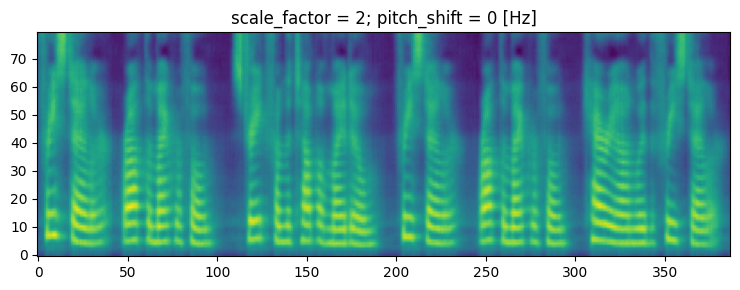

In [198]:
experiment(batch, scale_factor=2, pitch_shift=0, title='scale_factor = 2; pitch_shift = 0 [Hz]')

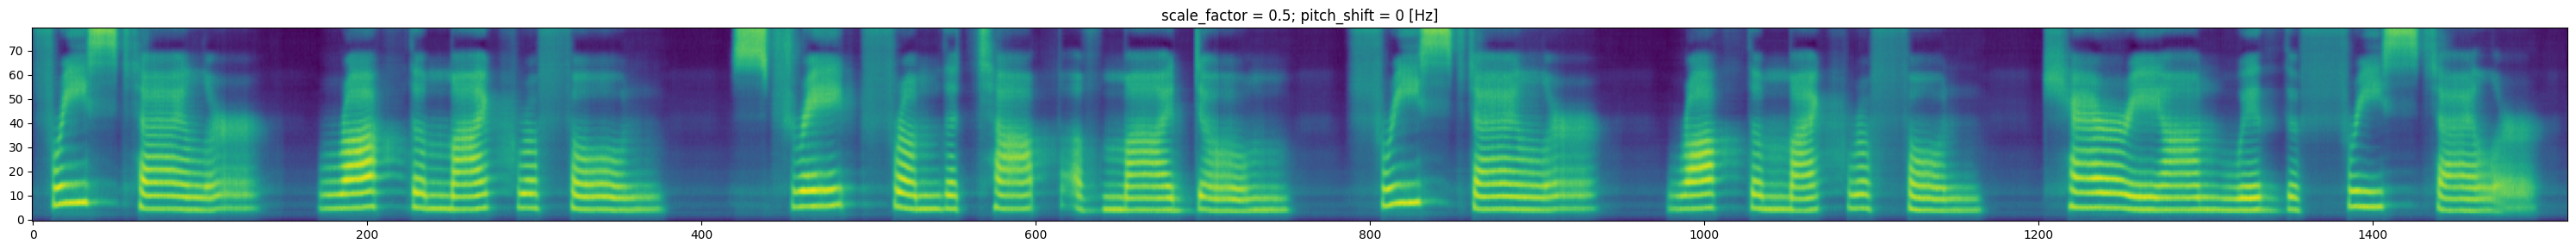

In [199]:
experiment(batch, scale_factor=0.5, pitch_shift=0, title='scale_factor = 0.5; pitch_shift = 0 [Hz]')

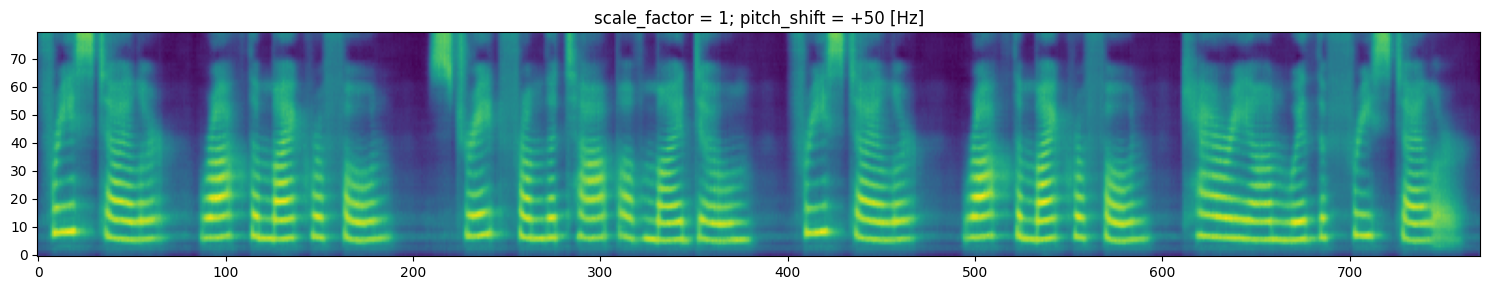

In [200]:
experiment(batch, scale_factor=1, pitch_shift=50, title='scale_factor = 1; pitch_shift = +50 [Hz]')

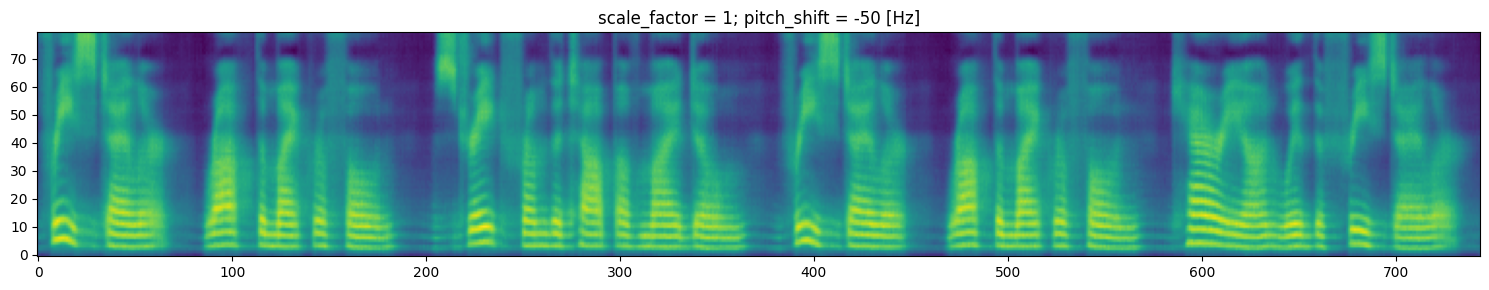

In [201]:
experiment(batch, scale_factor=1, pitch_shift=-50, title='scale_factor = 1; pitch_shift = -50 [Hz]')

Print loss and WER plots from tensorboard logs:

In [342]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def load_tb_logs(log_dir):
    event_files = [f for f in os.listdir(log_dir) if f.startswith("events.out")]
    if not event_files:
        raise FileNotFoundError(f"No event files found in {log_dir}")
    event_path = os.path.join(log_dir, event_files[-1])
    ea = EventAccumulator(event_path)
    ea.Reload()
    
    return ea

train_ea = load_tb_logs('logs/train')
val_ea = load_tb_logs('logs/val')

train_loss = [v.value for v in train_ea.scalars.Items('loss')]
train_steps = [v.step for v in train_ea.scalars.Items('loss')]

val_loss = [v.value for v in val_ea.scalars.Items('loss')]
val_steps = [v.step for v in val_ea.scalars.Items('loss')]

val_wer = [v.value for v in val_ea.scalars.Items('wer')]

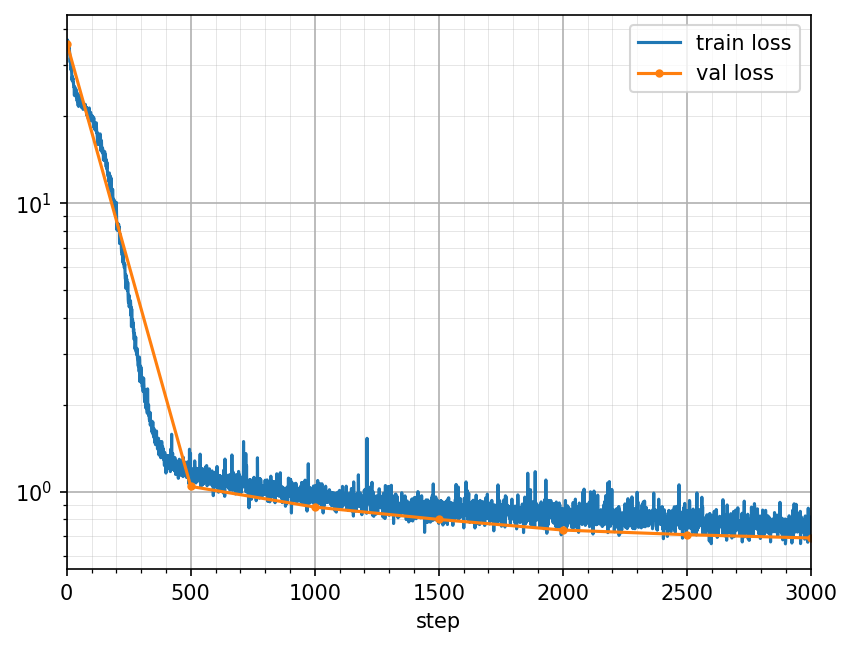

In [336]:
plt.figure(dpi=150)
plt.semilogy(train_steps, train_loss, label='train loss')
plt.semilogy(val_steps, val_loss, marker='.', label='val loss')
plt.xlim([0, train_steps[-1]])
plt.minorticks_on(); 
plt.grid(True, which='major'); plt.grid(True, which='minor', lw=0.3, alpha=0.5)
plt.xlabel('step')
plt.legend()
plt.show()

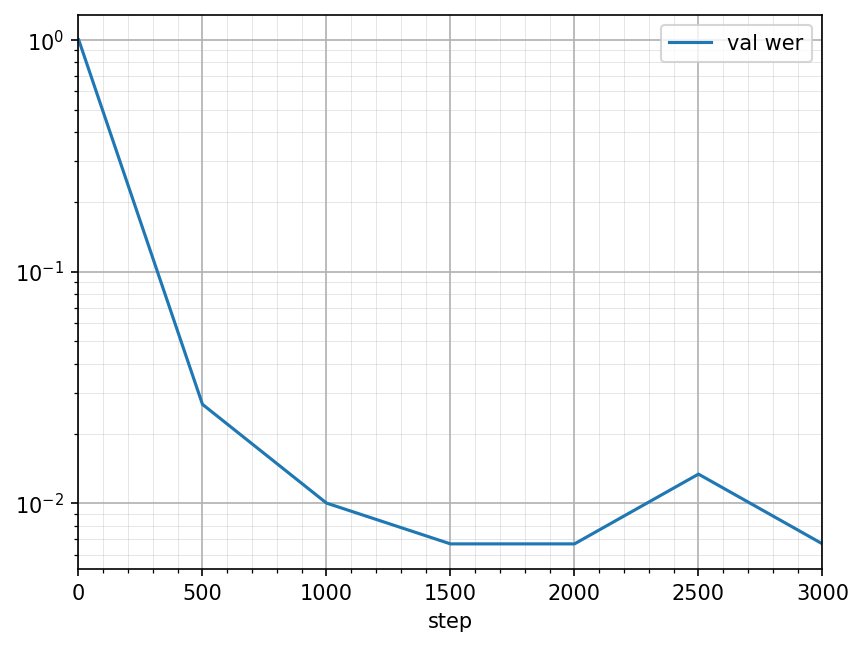

In [343]:
plt.figure(dpi=150)
plt.semilogy(val_steps, val_wer, label='val wer')
plt.xlim([0, train_steps[-1]])
plt.minorticks_on(); 
plt.grid(True, which='major'); plt.grid(True, which='minor', lw=0.3, alpha=0.5)
plt.xlabel('step')
plt.legend()
plt.show()